# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

P.S. Do NOT use odd system sizes, everything breaks because of the way that the polarized boundary conditions work.

# ED Implementation using QuSpin

## Reset Simulation

In [3]:
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states_dual")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values_dual")

# fetch the file you are studying
gc.collect()


791

In [1]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian, quantum_LinearOperator
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gc
import os
import shutil

# try breaking different symmetries
L        = 14 * 2
J        = 1

start    = 0.8
end      = 1.2
step     = 0.1

scan_var = "h"
values   = np.arange(start, end+step, step)
# values   = [10**i for i in np.arange(0, 2.1, 0.1)]
# values = values[:4]
opp      = "k" if scan_var == "h" else "h"
set      = 0.5

## Exact Diagonalization

In [ ]:
def exact_diagonalization_line(values, scan_var, opp, set, L, dual=False):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""
    
    if not os.path.exists("ed_results"):
        os.mkdir("ed_results")

    suffix = "_dual" if dual else ""
    folder_eigenstates = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states{suffix}"
    folder_eigenvalues = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values{suffix}"

    if not os.path.exists(folder_eigenstates):
        os.mkdir(folder_eigenstates)
        os.mkdir(folder_eigenvalues)
    else:
        return folder_eigenstates

    # select active sites
    start = 1 if dual else 0
    step = 2

    active_sites = list(range(start, L, step))
    L_active = len(active_sites)

    # define a reduced basis for only active sites
    basis = spin_basis_1d(L_active)

    for ind, val in tqdm(enumerate(values), total=len(values)):
        J = 1.0

        # scan variable assignment
        if scan_var == "h":
            h = val
            k_r = set
            k_l = set
        else:
            h = set
            k_r = val
            k_l = val

        # dual transformation
        if dual:
            h = 1/h
            k_r = k_r/h
            k_l = k_l/h

        # map active sites to 0..L_active-1 for QuSpin
        idx_map = {site: i for i, site in enumerate(active_sites)}

        # build Hamiltonian terms
        J_term = [[J, idx_map[i], idx_map[(i+2) % L]] for i in active_sites]
        h_term = [[h, idx_map[i]] for i in active_sites]
        xy_term = [[k_r, idx_map[i], idx_map[(i+4)%L]] for i in active_sites]
        yx_term = [[-k_l, idx_map[i], idx_map[(i+4)%L]] for i in active_sites]
        xyz_term = [[k_l, idx_map[i], idx_map[(i+2)%L],idx_map[(i+4)%L]] for i in active_sites]
        zyx_term = [[-k_r,  idx_map[i], idx_map[(i+2)%L],idx_map[(i+4)%L]] for i in active_sites]
        static = [
            ["xx", J_term],
            ["z", h_term],
            ["xy", xy_term],
            ["yx", yx_term],
            ["xyz", xyz_term], 
            ["zyx", zyx_term]
        ]

        # tiny symmetry-breaking field to lift residual degeneracy
        g = 5e-3
        # static.append(["x", [[(-1)**i * g, i] for i in range(L_active)]])

        print(f"Running for (J,h, kl, kr) = {J}, {h}, {k_l}, {k_r}")
        print(static)

        # construct Hamiltonian
        H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)

        # low-energy eigenvalues
        E, psi = H.eigsh(k=10, which="SA")

        # save results
        np.savetxt(os.path.join(folder_eigenvalues, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_energies"), E)

        # save first few eigenvectors
        n = 1
        for i in range(n):
            psi_temp = psi[:, i]
            np.save(os.path.join(folder_eigenstates, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_state_{i}"), psi_temp)

    return folder_eigenstates

results = exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, L=L)
results1 = exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, L=L, dual=True)



  0%|          | 0/5 [00:00<?, ?it/s]

Running for (J,h, kl, kr) = 1.0, 0.8, 0.5, 0.5
[['xx', [[1.0, 0, 1], [1.0, 1, 2], [1.0, 2, 3], [1.0, 3, 4], [1.0, 4, 5], [1.0, 5, 6], [1.0, 6, 7], [1.0, 7, 8], [1.0, 8, 9], [1.0, 9, 10], [1.0, 10, 11], [1.0, 11, 12], [1.0, 12, 13], [1.0, 13, 0]]], ['z', [[np.float64(0.8), 0], [np.float64(0.8), 1], [np.float64(0.8), 2], [np.float64(0.8), 3], [np.float64(0.8), 4], [np.float64(0.8), 5], [np.float64(0.8), 6], [np.float64(0.8), 7], [np.float64(0.8), 8], [np.float64(0.8), 9], [np.float64(0.8), 10], [np.float64(0.8), 11], [np.float64(0.8), 12], [np.float64(0.8), 13]]], ['xy', [[0.5, 0, 2], [0.5, 1, 3], [0.5, 2, 4], [0.5, 3, 5], [0.5, 4, 6], [0.5, 5, 7], [0.5, 6, 8], [0.5, 7, 9], [0.5, 8, 10], [0.5, 9, 11], [0.5, 10, 12], [0.5, 11, 13], [0.5, 12, 0], [0.5, 13, 1]]], ['yx', [[-0.5, 0, 2], [-0.5, 1, 3], [-0.5, 2, 4], [-0.5, 3, 5], [-0.5, 4, 6], [-0.5, 5, 7], [-0.5, 6, 8], [-0.5, 7, 9], [-0.5, 8, 10], [-0.5, 9, 11], [-0.5, 10, 12], [-0.5, 11, 13], [-0.5, 12, 0], [-0.5, 13, 1]]], ['xyz', [[0.5, 0,

 20%|██        | 1/5 [00:03<00:14,  3.74s/it]

Running for (J,h, kl, kr) = 1.0, 0.9, 0.5, 0.5
[['xx', [[1.0, 0, 1], [1.0, 1, 2], [1.0, 2, 3], [1.0, 3, 4], [1.0, 4, 5], [1.0, 5, 6], [1.0, 6, 7], [1.0, 7, 8], [1.0, 8, 9], [1.0, 9, 10], [1.0, 10, 11], [1.0, 11, 12], [1.0, 12, 13], [1.0, 13, 0]]], ['z', [[np.float64(0.9), 0], [np.float64(0.9), 1], [np.float64(0.9), 2], [np.float64(0.9), 3], [np.float64(0.9), 4], [np.float64(0.9), 5], [np.float64(0.9), 6], [np.float64(0.9), 7], [np.float64(0.9), 8], [np.float64(0.9), 9], [np.float64(0.9), 10], [np.float64(0.9), 11], [np.float64(0.9), 12], [np.float64(0.9), 13]]], ['xy', [[0.5, 0, 2], [0.5, 1, 3], [0.5, 2, 4], [0.5, 3, 5], [0.5, 4, 6], [0.5, 5, 7], [0.5, 6, 8], [0.5, 7, 9], [0.5, 8, 10], [0.5, 9, 11], [0.5, 10, 12], [0.5, 11, 13], [0.5, 12, 0], [0.5, 13, 1]]], ['yx', [[-0.5, 0, 2], [-0.5, 1, 3], [-0.5, 2, 4], [-0.5, 3, 5], [-0.5, 4, 6], [-0.5, 5, 7], [-0.5, 6, 8], [-0.5, 7, 9], [-0.5, 8, 10], [-0.5, 9, 11], [-0.5, 10, 12], [-0.5, 11, 13], [-0.5, 12, 0], [-0.5, 13, 1]]], ['xyz', [[0.5, 0,

 40%|████      | 2/5 [00:06<00:08,  2.98s/it]

...

 60%|██████    | 3/5 [00:05<00:03,  1.82s/it]

Running for (J,h, kl, kr) = 1.0, 0.9090909090909091, 0.55, 0.55
[['xx', [[1.0, 0, 1], [1.0, 1, 2], [1.0, 2, 3], [1.0, 3, 4], [1.0, 4, 5], [1.0, 5, 6], [1.0, 6, 7], [1.0, 7, 8], [1.0, 8, 9], [1.0, 9, 10], [1.0, 10, 11], [1.0, 11, 12], [1.0, 12, 13], [1.0, 13, 0]]], ['z', [[np.float64(0.9090909090909091), 0], [np.float64(0.9090909090909091), 1], [np.float64(0.9090909090909091), 2], [np.float64(0.9090909090909091), 3], [np.float64(0.9090909090909091), 4], [np.float64(0.9090909090909091), 5], [np.float64(0.9090909090909091), 6], [np.float64(0.9090909090909091), 7], [np.float64(0.9090909090909091), 8], [np.float64(0.9090909090909091), 9], [np.float64(0.9090909090909091), 10], [np.float64(0.9090909090909091), 11], [np.float64(0.9090909090909091), 12], [np.float64(0.9090909090909091), 13]]], ['xy', [[np.float64(0.55), 0, 2], [np.float64(0.55), 1, 3], [np.float64(0.55), 2, 4], [np.float64(0.55), 3, 5], [np.float64(0.55), 4, 6], [np.float64(0.55), 5, 7], [np.float64(0.55), 6, 8], [np.float64(0.

 80%|████████  | 4/5 [00:07<00:01,  1.78s/it]

Running for (J,h, kl, kr) = 1.0, 0.8333333333333334, 0.6, 0.6
[['xx', [[1.0, 0, 1], [1.0, 1, 2], [1.0, 2, 3], [1.0, 3, 4], [1.0, 4, 5], [1.0, 5, 6], [1.0, 6, 7], [1.0, 7, 8], [1.0, 8, 9], [1.0, 9, 10], [1.0, 10, 11], [1.0, 11, 12], [1.0, 12, 13], [1.0, 13, 0]]], ['z', [[np.float64(0.8333333333333334), 0], [np.float64(0.8333333333333334), 1], [np.float64(0.8333333333333334), 2], [np.float64(0.8333333333333334), 3], [np.float64(0.8333333333333334), 4], [np.float64(0.8333333333333334), 5], [np.float64(0.8333333333333334), 6], [np.float64(0.8333333333333334), 7], [np.float64(0.8333333333333334), 8], [np.float64(0.8333333333333334), 9], [np.float64(0.8333333333333334), 10], [np.float64(0.8333333333333334), 11], [np.float64(0.8333333333333334), 12], [np.float64(0.8333333333333334), 13]]], ['xy', [[np.float64(0.6), 0, 2], [np.float64(0.6), 1, 3], [np.float64(0.6), 2, 4], [np.float64(0.6), 3, 5], [np.float64(0.6), 4, 6], [np.float64(0.6), 5, 7], [np.float64(0.6), 6, 8], [np.float64(0.6), 7, 9]

100%|██████████| 5/5 [00:09<00:00,  1.83s/it]


## Energy Profile

/home/silvanita/Desktop/thesis/master_thesis/books/ed_results/L28_k0.5_h0.8-1.2_values
kh_0.5000000000_0.8000000000_energies


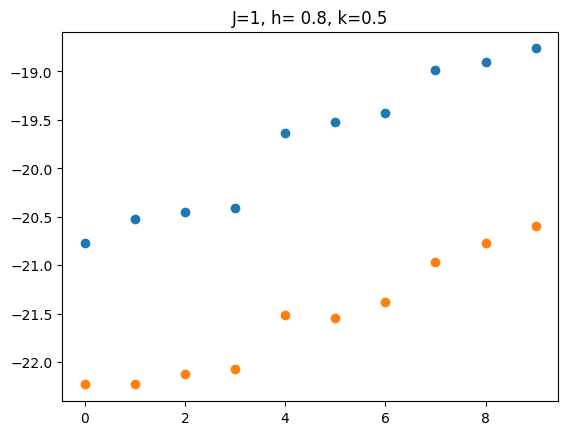

kh_0.5000000000_0.9000000000_energies


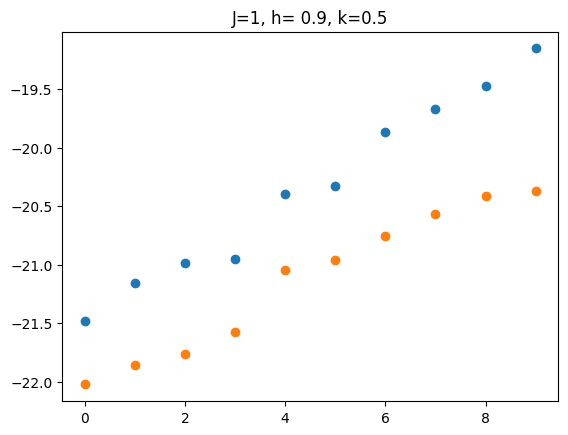

kh_0.5000000000_1.0000000000_energies


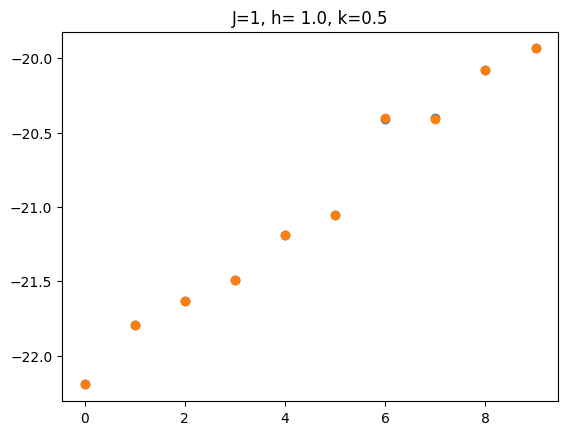

kh_0.5000000000_1.1000000000_energies


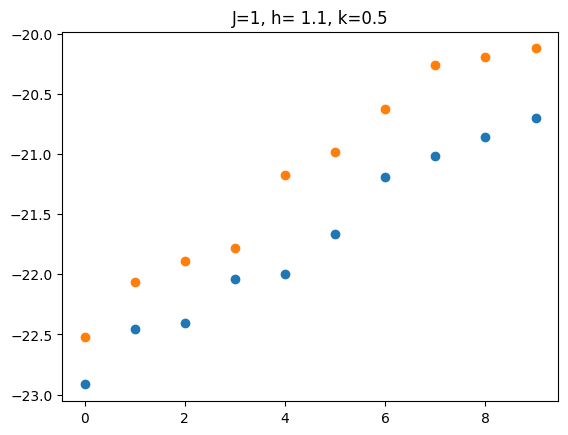

kh_0.5000000000_1.2000000000_energies


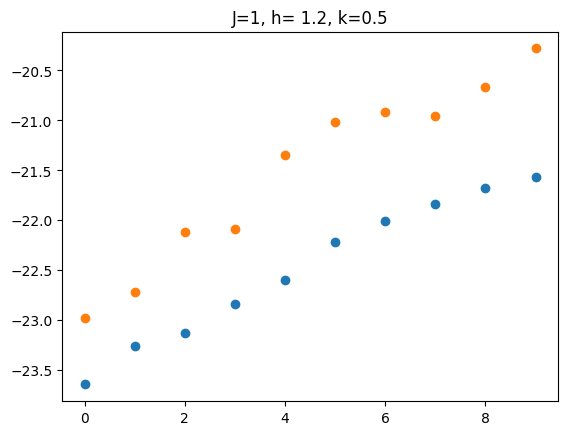

In [7]:
# plot energy spectrum
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
loc = os.path.join(os.getcwd(), f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
print(loc)

gs_energy = []
for (i, v) in zip(sorted(os.listdir(loc), key=lambda x: float(x.split('_')[2])), values):
    print(i)
    energy = np.loadtxt(os.path.join(loc, i))
    energy_dual = np.loadtxt(os.path.join(loc+"_dual", i))
    # energy = sorted(energy)
    plt.scatter(range(len(energy)), energy)
    plt.scatter(range(len(energy_dual)), energy_dual)
    gs_energy.append(energy[0])
    plt.title(f"J={J}, {scan_var}= {v}, {opp}={set}")
    plt.show()


## Topological Phases

What we are trying to look for is the existence of strong zero modes in our system. Maybe it is there, maybe it is not. We do this by noting that in the presence of SZM, we have the expected scaling for the parity gap:
$$ \Delta_p = | E_{even} - E_{odd}| \propto \exp{(-\frac{N}{\xi_{zm}})}$$
for some zero mode correlation length $\xi_{zm}$

In [13]:
def exact_diagonalization_parity(L, params, dual=False):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""

    active_sites = list(range(L))

    # define a reduced basis for only active sites
    basis_even = spin_basis_1d(int(L), zblock=+1)
    basis_odd = spin_basis_1d(int(L), zblock=-1)
    J, h, k = params

    # map active sites to 0..L_active-1 for QuSpin
    idx_map = {site: i for i, site in enumerate(active_sites)}

    # build Hamiltonian terms
    J_term = [[J, idx_map[i], idx_map[(i+1)]] for i in range(L-1)]
    h_term = [[-h, idx_map[i]] for i in range(L)]
    # xy_term = [[k, idx_map[i], idx_map[(i+2)]] for i in range(L-2)]
    # yx_term = [[-k, idx_map[i], idx_map[(i+2)]] for i in range(L-2)]
    # xyz_term = [[k, idx_map[i], idx_map[(i+1)],idx_map[(i+2)]] for i in range(L-2)]
    # zyx_term = [[-k,  idx_map[i], idx_map[(i+1)],idx_map[(i+2)]] for i in range(L-2)]

    # build the paper's hamiltonians
    xx_term = [[k, idx_map[i], idx_map[i+2]] for i in range(L-2)]
    zz_term = [[k, idx_map[i], idx_map[i+1]] for i in range(L-1)]
    static = [
        ["xx", J_term],
        ["z", h_term],
        ['xx', xx_term],
        ['zz', zz_term]
        # ["xy", xy_term],
        # ["yx", yx_term],
        # ["xyz", xyz_term], 
        # ["zyx", zyx_term]
    ]

    # tiny symmetry-breaking field to lift residual degeneracy
    g = 5e-3
    # static.append(["x", [[(-1)**i * g, i] for i in range(L)]])

    # construct Hamiltonians in each parity sector
    H_even = hamiltonian(
        static, [], basis=basis_even,
        dtype=np.complex128, check_symm=False, check_herm=False
    )

    H_odd = hamiltonian(
        static, [], basis=basis_odd,
        dtype=np.complex128, check_symm=False, check_herm=False
    )

    # lowest-energy eigenvalue in each sector
    E_even = H_even.eigsh(k=1, which="SA", return_eigenvectors=False)[0]
    E_odd  = H_odd.eigsh(k=1, which="SA", return_eigenvectors=False)[0]

    return E_even - E_odd

L = 16
K = 0.1
H = np.arange(0, 1.01, 0.05)
# for h in tqdm(H):
#     params = (1, h, K)
#     Es = exact_diagonalization_parity(L, params, dual=False)
#     E_even, E_odd = Es
#     avg = 0.5*(E_even + E_odd)

#     even_energies.append(E_even - avg)
#     odd_energies.append(E_odd - avg)

energy_differences = []
L = np.arange(5, 16)
K = 0
H = 0.5
for l in tqdm(L):
    params = (1, H, K)
    Es = exact_diagonalization_parity(l, params, dual=False)
    
    # plt.scatter(range(len(E_even)), E_even, label="even")
    # plt.scatter(range(len(E_odd)), E_odd, alpha=0.7, marker="x", label="odd")
    # plt.title(f"L={l}")
    # plt.legend()
    # plt.show()
    energy_differences.append(np.abs(Es))


100%|██████████| 11/11 [00:03<00:00,  3.54it/s]


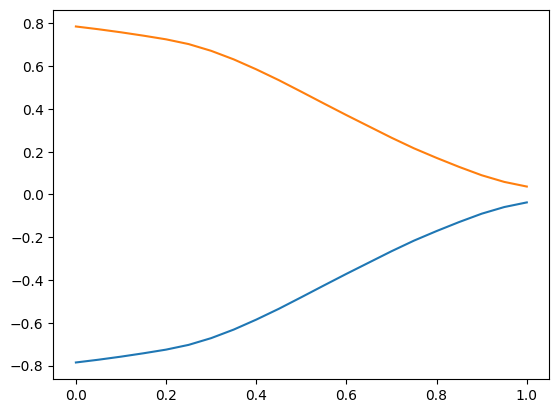

In [ ]:
# even_energies = np.array(even_energies)
# odd_energies = np.array(odd_energies)

plt.plot(H, even_energies)
plt.plot(H, odd_energies)


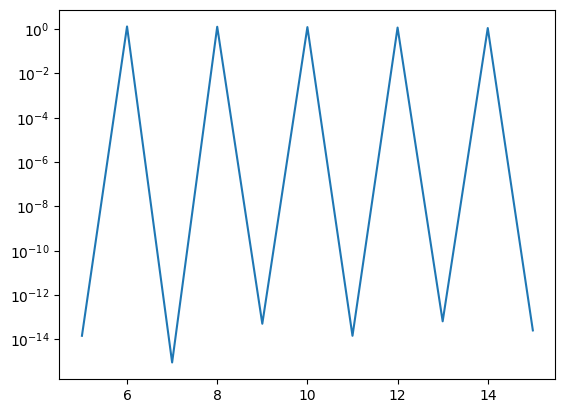

In [15]:
plt.semilogy(L, np.abs(energy_differences).T)

In [75]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import numpy as np

def model_gap(L, J=1.0, h=0.5, k=0.1):
    basis = spin_basis_1d(int(L))

    static = [
        ["xx", [[J, i, i+1] for i in range(L-1)]],
        ["z",  [[h, i] for i in range(L)]],
        ['xx', [[k, i, i+2]for i in range(L-2)] ],
        ['zz', [[k, i, i+1]for i in range(L-2)] ],
        # ["xy", [[k, i, i+2] for i in range(L-2)]],
        # ["yx",[[-k, i, i+2] for i in range(L-2)]],
        # ["xyz", [[k, i, i+1, i+2] for i in range(L-2)]],
        # ["zyx", [[-k,  i, i+1, i+2] for i in range(L-2)]]
    ]

    H = hamiltonian(static, [], basis=basis, check_symm=False, check_herm=False)

    E, V= H.eigsh(k=4, which="SA")
    P_op = hamiltonian( [["z"*L, [[1.0] + list(range(L))]]], [], basis=basis, check_symm=False, check_herm=False)
    parities = np.array([np.vdot(V[:,i], P_op.dot(V[:,i])) for i in range(4)])

    even_check = (parities > 0)
    odd_check = (parities < 0)

    E_even = np.min(E[even_check])
    E_odd = np.min(E[odd_check])
    
    Delta_p = abs(E_even - E_odd)
    return Delta_p

In [ ]:
Ls = np.arange(4, 17)
gaps = np.array([model_gap(L) for L in Ls])


KeyboardInterrupt: 

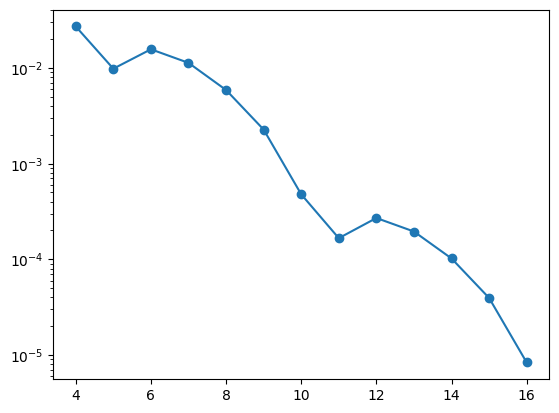

In [26]:
import matplotlib.pyplot as plt
plt.semilogy(Ls, gaps, 'o-')
plt.show()

In [83]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from tqdm import tqdm

def find_xi(lengths, energies, plotting=False):

    def line(x, xi, A):
        return A + np.exp(-x/xi)

    peaks, _ = find_peaks(energies)
    if len(peaks) < 2:
        return 0
    popt, _ = curve_fit(line, lengths[peaks], energies[peaks])

    if plotting:
        plt.semilogy(lengths, energies)
        plt.semilogy(lengths, line(lengths, *popt), label=f"{popt}")
        plt.legend()
        plt.show()

    return popt[0]

def find_q(lengths, energies, xi, plotting=False):
    def sinewave(x, q, phi):
        return np.abs(np.sin(q*x+phi))
    
    energies_rescaled = energies * np.exp(lengths/xi) 
    energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))

    peaks, _ = find_peaks(energies_rescaled)
    if len(peaks) < 2:
        return 0

    wavevector_guess = 2*np.abs(lengths[peaks[0]] - lengths[peaks[1]])
    popt, _ = curve_fit(sinewave, lengths, energies_rescaled, p0=[2*np.pi / wavevector_guess, lengths[peaks[0]]])

    if plotting:
        plt.plot(lengths, energies_rescaled, label="oscillations")
        plt.scatter(lengths[peaks], energies_rescaled[peaks])
        plt.plot(lengths, sinewave(lengths, *popt), label=f"q={popt[0]}")
        plt.legend()
        plt.show()

    return popt[0]

H = np.arange(0.1, 1, 0.1)
K = 0.1
Ls = np.arange(4, 18)

correlation_lengths = []
wavevectors = []
for h in tqdm(H):
    gaps = np.array([model_gap(L, h=h, k=K) for L in Ls])

    xi = find_xi(Ls, gaps)
    q = find_q(Ls, gaps, xi)

    correlation_lengths.append(xi)
    wavevectors.append(q)

  0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_11025/4055769475.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(line, lengths[peaks], energies[peaks])
 22%|██▏       | 2/9 [04:51<16:58, 145.54s/it]/tmp/ipykernel_11025/4055769475.py:27: RuntimeWarning: divide by zero encountered in divide
  energies_rescaled = energies * np.exp(lengths/xi)
/tmp/ipykernel_11025/4055769475.py:28: RuntimeWarning: invalid value encountered in subtract
  energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))
/tmp/ipykernel_11025/4055769475.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))
100%|██████████| 9/9 [15:29<00:00, 103.32s/it]


[np.float64(7.2138886810677745), np.float64(0.8996140562316616), np.float64(0.9542197685526143), 0, 0, np.float64(1.100177829086468), 0, 0, 0, 0]
[np.float64(0.7054428923867164), np.float64(1.4844128508354646), np.float64(1.03310574557773), 0, 0, np.float64(0.6467881213418823), 0, 0, 0, 0]


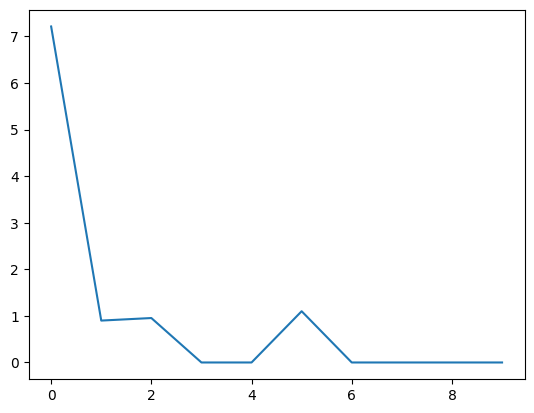

In [80]:
print(correlation_lengths)
print(wavevectors)

plt.plot(correlation_lengths)
# plt.plot(wavevectors)

In [2]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import numpy as np

def model_gap(L, J=1.0, h=1.5, k=0.2):
    basis = spin_basis_1d(int(L))

    static = [
        ["xx", [[J, i, i+1] for i in range(L-1)]],
        ["z",  [[-h, i] for i in range(L)]],
        ["zz", [[k, i, i+1] for i in range(L-1)]],
        ["xx", [[k, i, i+2] for i in range(L-2)]]
        # ["xy", [[k, i, i+2] for i in range(L-2)]],
        # ["yx",[[-k, i, i+2] for i in range(L-2)]],
        # ["xyz", [[k, i, i+1, i+2] for i in range(L-2)]],
        # ["zyx", [[-k,  i, i+1, i+2] for i in range(L-2)]]
    ]

    H = hamiltonian(static, [], basis=basis)

    E, V= H.eigsh(k=4, which="SA")
    P_op = hamiltonian( [["z"*L, [[1.0] + list(range(L))]]], [], basis=basis )
    parities = np.array([np.vdot(V[:,i], P_op.dot(V[:,i])) for i in range(4)])

    even_check = (parities > 0)
    odd_check = (parities < 0)

    E_even = np.min(E[even_check])
    E_odd = np.min(E[odd_check])
    
    Delta_p = abs(E_even - E_odd)
    average = 0.5 * (E_even + E_odd)
    even_diff = E_even - average
    odd_diff = E_odd - average
    return np.array([even_diff, odd_diff])

L=14
h = np.arange(0, 6, 0.1)
gaps = [model_gap(L, k=hx) for hx in h]

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


In [72]:
from scipy.optimize import root_scalar
even_diff, odd_diff = np.array(gaps).T

plt.plot(h, even_diff, ls="--",label="even parity")
plt.plot(h, odd_diff, ls="--",label="odd parity")
# plt.xlim(0, 0.8)
lim = 1e-4
# plt.ylim(lim, -lim)
zero_crossings = []
for i in range(len(even_diff)-1):
    if even_diff[i] * even_diff[i+1] < 0:
        zero_crossings.append(i)

plt.scatter(h[zero_crossings], [0]*len(zero_crossings), marker='x', c='red')

plt.grid()
plt.legend()
plt.ylabel(r"E - $\tilde{E}$")
plt.xlabel(r"$h$")
plt.title(r"$\Delta_p$ for k=0.1")

ValueError: too many values to unpack (expected 2)

## Duality

In principle, we should be able to find

In [49]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian, quantum_LinearOperator
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gc
import os
import shutil

def exact_diagonalization_lengths(L, params, dual=False):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""
    J, h, k = params

    homey = f"ed_lengths/{J}-{h}-{k}-dual" if dual else f"ed_lengths/{J}-{h}-{k}"
    homey = os.path.join(os.getcwd(), homey)
    if not os.path.exists(homey):
        os.mkdir(homey)

    folder_eigenstates = homey + f"/L{L}_states"
    folder_eigenvalues = homey + "/energies"

    active_sites = list(range(L))
    basis = spin_basis_1d(int(L))

    # map active sites to 0..L_active-1 for QuSpin
    idx_map = {site: i for i, site in enumerate(active_sites)}

    if dual:
        k = k/h
        h = 1/h
    print(J, h, k)
    # build Hamiltonian terms
    J_term = [[J, idx_map[i], idx_map[(i+1) % L]] for i in active_sites]
    h_term = [[h, idx_map[i]] for i in active_sites]
    xy_term = [[k, idx_map[i], idx_map[(i+2)%L]] for i in active_sites]
    yx_term = [[-k, idx_map[i], idx_map[(i+2)%L]] for i in active_sites]
    xyz_term = [[k, idx_map[i], idx_map[(i+1)%L],idx_map[(i+2)%L]] for i in active_sites]
    zyx_term = [[-k,  idx_map[i], idx_map[(i+1)%L],idx_map[(i+2)%L]] for i in active_sites]

    static = [
        ["xx", J_term],
        ["z", h_term],
        ["xy", xy_term],
        ["yx", yx_term],
        ["xyz", xyz_term], 
        ["zyx", zyx_term]
    ]

    # tiny symmetry-breaking field to lift residual degeneracy
    g = 5e-3
    static.append(["x", [[(-1)**i * g, i] for i in range(L)]])

    H = hamiltonian(
        static, [], basis=basis,
        dtype=np.complex128, check_symm=False, check_herm=False
    )

    E, psi = H.eigsh(k=10, which="SA")
    # plt.plot(E)
    # plt.show()
    with open(folder_eigenvalues, 'a') as file:
        file.write(f"{E[0]}\n")

    # save first few eigenvectors
    n = 1
    for i in range(n):
        psi_temp = psi[:, i]
        np.save(folder_eigenstates, psi_temp)

energies = []

J = 1
h = 0.5
k = 0.5
L = np.arange(5, 21, 1)

folder_eigenvalues = f"ed_lengths/{J}-{h}-{k}-dual/energies"
if os.path.exists(folder_eigenvalues):
    os.remove(folder_eigenvalues)
folder_eigenvalues = f"ed_lengths/{J}-{h}-{k}/energies"
if os.path.exists(folder_eigenvalues):
    os.remove(folder_eigenvalues)

       
for l in tqdm(L):
    params = (J, h, k)
    print("regular:")
    exact_diagonalization_lengths(l, params)
    print("dual:")
    exact_diagonalization_lengths(l, params, dual=True)



 25%|██▌       | 4/16 [00:00<00:00, 23.67it/s]

regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0


 44%|████▍     | 7/16 [00:00<00:01,  7.65it/s]

regular:
1 0.5 0.5
dual:
1 2.0 1.0
regular:
1 0.5 0.5
dual:
1 2.0 1.0


 56%|█████▋    | 9/16 [00:01<00:01,  3.53it/s]

...

 88%|████████▊ | 14/16 [01:37<00:42, 21.08s/it]

regular:
1 0.5 0.5
dual:
1 2.0 1.0


 94%|█████████▍| 15/16 [03:46<00:50, 50.47s/it]

regular:
1 0.5 0.5
dual:
1 2.0 1.0


100%|██████████| 16/16 [08:33<00:00, 32.09s/it] 


## Magnetization Profile

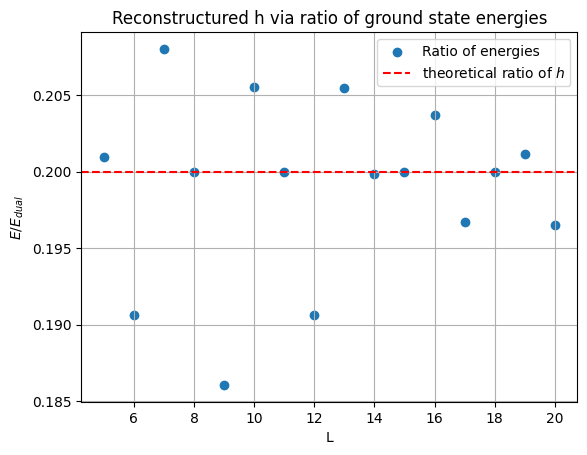

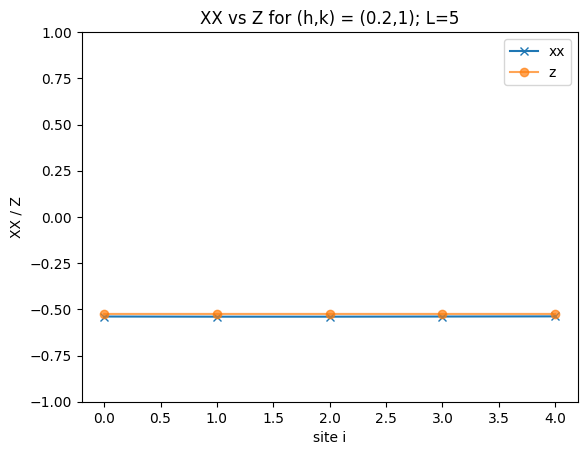

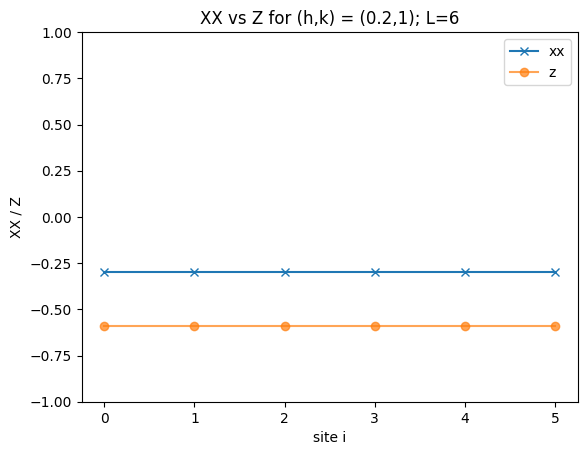

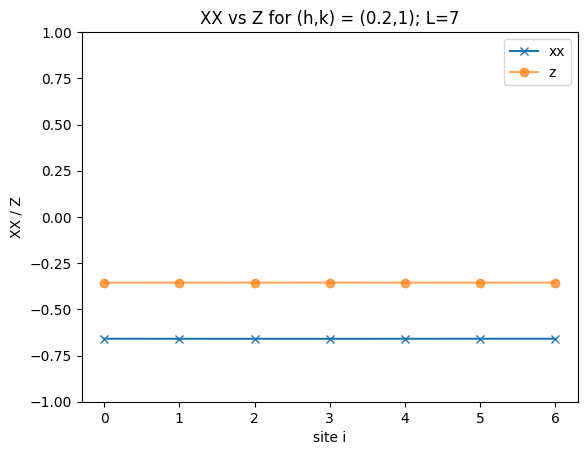

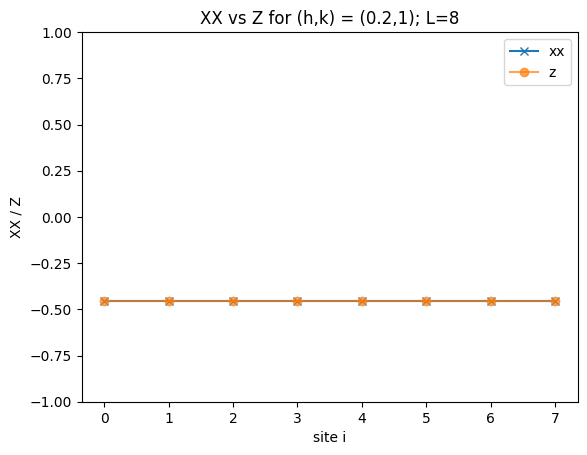

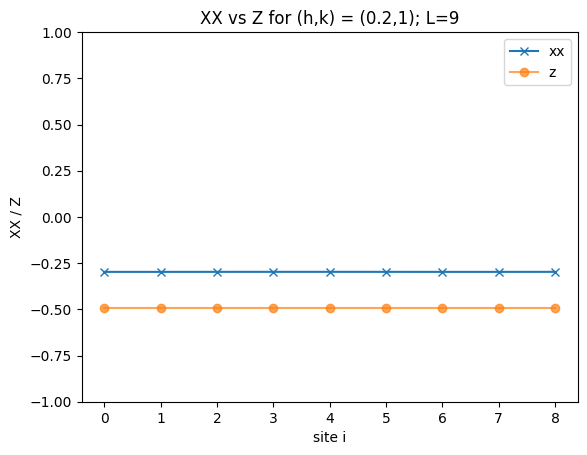

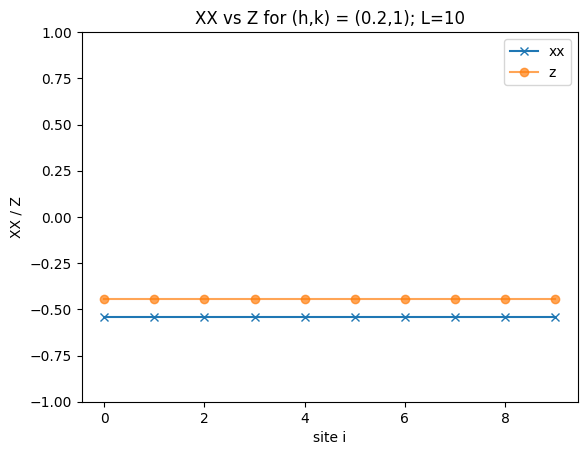

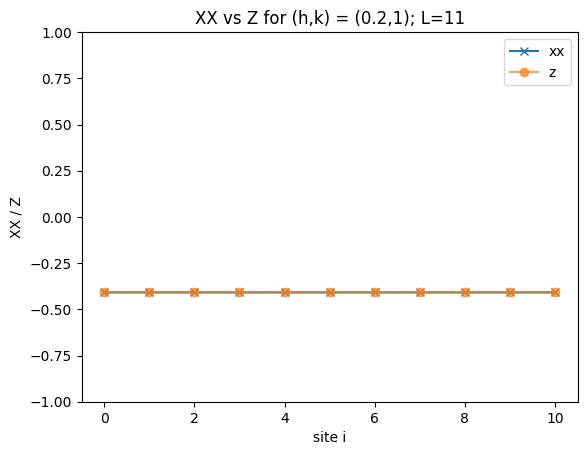

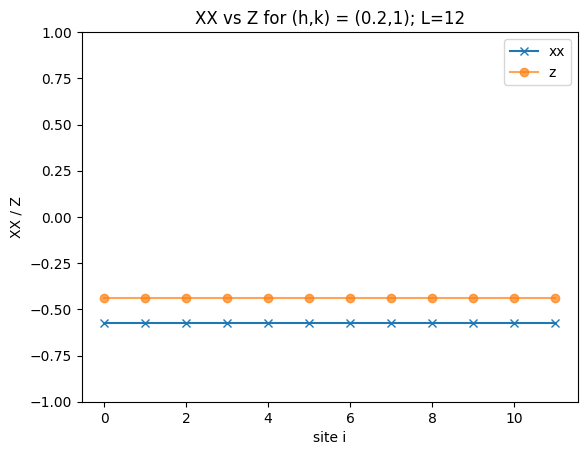

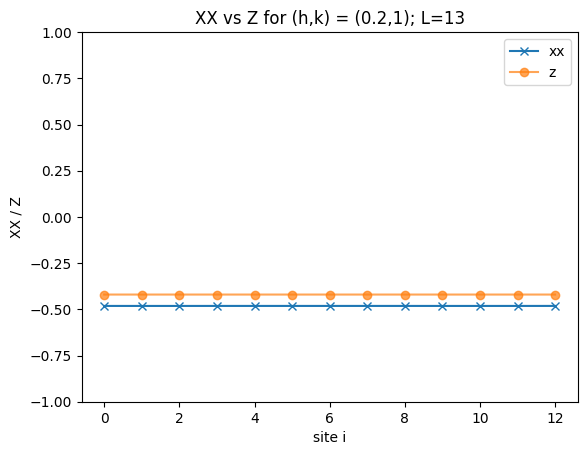

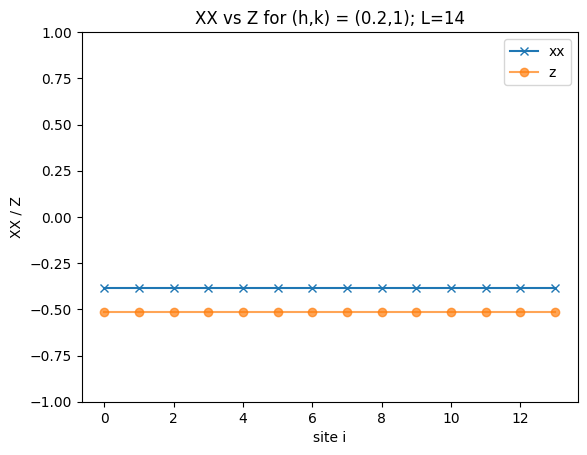

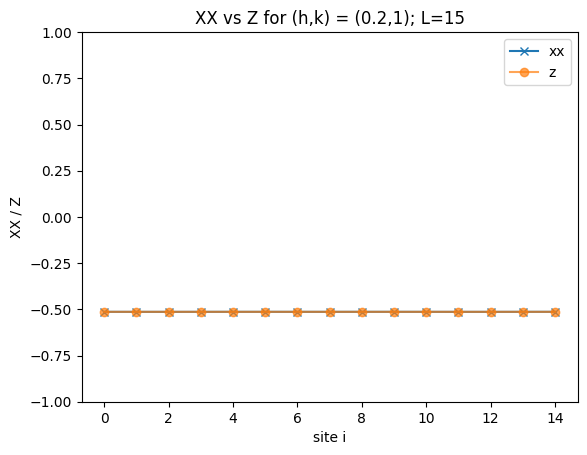

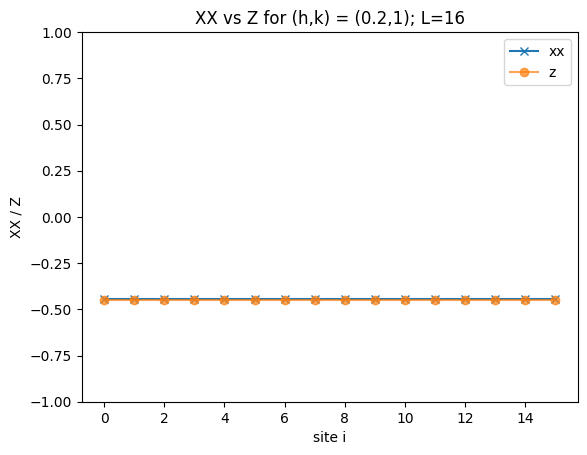

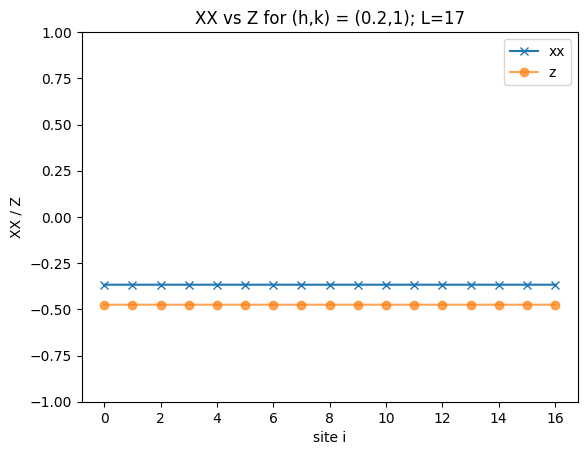

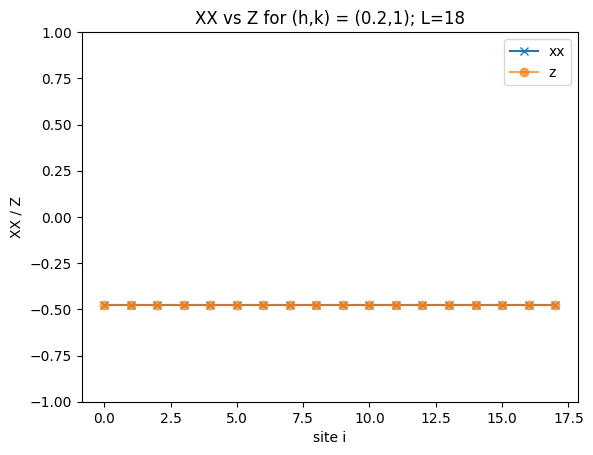

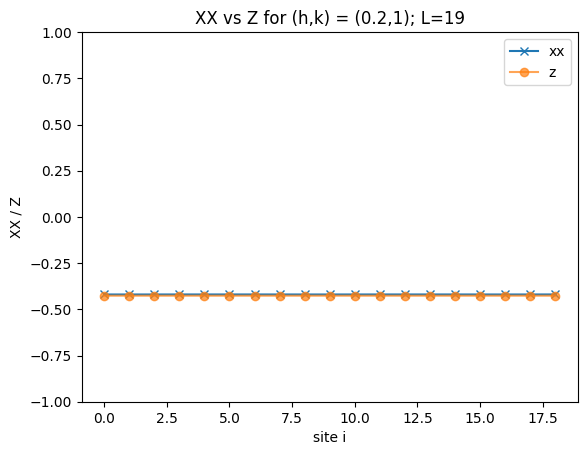

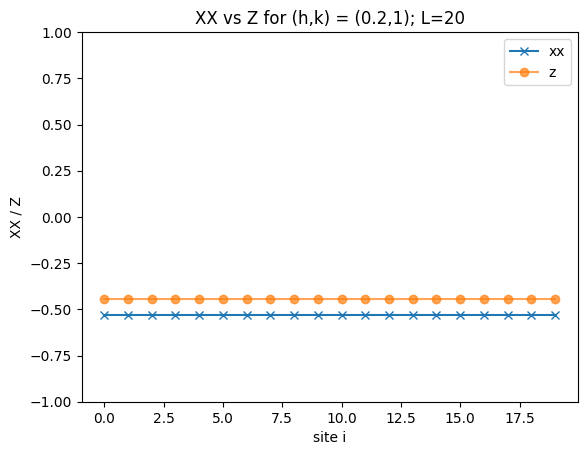

In [37]:
def magnetization_string(op, psi, dist=1):
    """
    Measure <op_i op_{i+dist} ...> on even (regular) or odd (dual) sites.
    The basis is inferred from the size of psi.
    """

    # infer active lattice size
    L_active = int(np.log2(psi.size))
    basis = spin_basis_1d(L_active)

    # determine site mapping
    start = 0
    step = 1

    active_sites = list(range(start, L_active, step))
    idx_map = {site: i for i, site in enumerate(active_sites)}

    n_ops = len(op)
    values = []

    for i in active_sites:
        # reindex sites to 0..L_active-1
        indices = [idx_map[(i + j*dist) % L_active] for j in range(n_ops)]

        static = [
            [op, [[1.0, *indices]]]
        ]
        operator = quantum_LinearOperator(
            static,
            basis=basis,
            check_symm=False,
            check_herm=False,
            dtype=np.complex128,
        )

        val = operator.expt_value(psi)
        values.append(np.real(val))

    return np.array(values)

results = os.path.join(os.getcwd(), f"ed_lengths/{J}-{h}-{k}")

energies_dual = np.loadtxt(os.path.join(results+"-dual", "energies")).T
energies = np.loadtxt(os.path.join(results+"", "energies")).T
reconstructed_h = energies/energies_dual

plt.title("Reconstructured h via ratio of ground state energies")
plt.scatter(L, reconstructed_h, label="Ratio of energies")
plt.axhline(h, c="red",ls = "--", label=r"theoretical ratio of $h$")
plt.legend()
plt.grid()
plt.xlabel("L")
plt.ylabel(r"$E / E_{dual}$")
plt.show()

XX_bulk = []
Z_bulk = []

files = [
    f for f in os.listdir(results)
    if f != "energies"
]

# Sort based on l, which is the integer before the underscore
files.sort(key=lambda x: int(x.split("_")[0][1:]))

for i in files:
    if i == "energies":
        continue
    l = int(i.split("_")[0][1:])

    psi = np.load(os.path.join(results,i))
    psi_dual = np.load(os.path.join(results+"-dual", i))

    sites = np.arange(0, l, 1)

    XX = magnetization_string("xx", psi, dist=1)
    Z  = magnetization_string("z", psi_dual, dist=1)

    XX_bulk.append(np.mean(XX[1:-1]))
    Z_bulk.append(np.mean(Z[1:-1]))

    plt.plot(sites, XX, marker="x", label="xx")
    plt.plot(sites, Z, marker="o", alpha=0.7, label="z")

    plt.ylim(-1, 1)
    plt.title(f"XX vs Z for (h,k) = ({h},{k}); L={l}")
    plt.xlabel("site i")
    plt.ylabel("XX / Z")
    plt.legend()
    plt.show()

In [48]:
integers = np.arange(100)
sizes = 3.4 * integers + 8
sizes = np.round(sizes)
print(sizes)

[  8.  11.  15.  18.  22.  25.  28.  32.  35.  39.  42.  45.  49.  52.
  56.  59.  62.  66.  69.  73.  76.  79.  83.  86.  90.  93.  96. 100.
 103. 107. 110. 113. 117. 120. 124. 127. 130. 134. 137. 141. 144. 147.
 151. 154. 158. 161. 164. 168. 171. 175. 178. 181. 185. 188. 192. 195.
 198. 202. 205. 209. 212. 215. 219. 222. 226. 229. 232. 236. 239. 243.
 246. 249. 253. 256. 260. 263. 266. 270. 273. 277. 280. 283. 287. 290.
 294. 297. 300. 304. 307. 311. 314. 317. 321. 324. 328. 331. 334. 338.
 341. 345.]


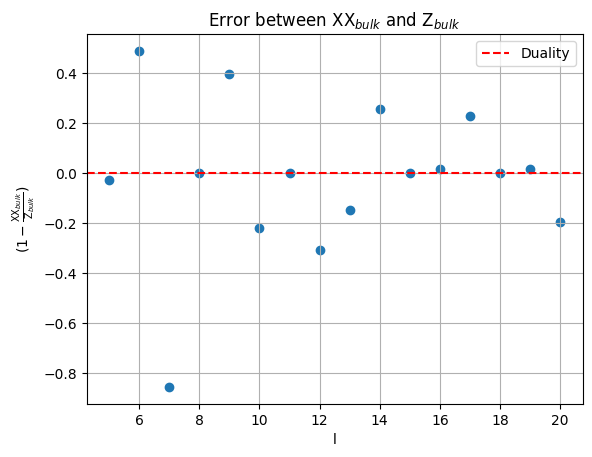

In [30]:
from scipy.optimize import curve_fit

odd_sites = L

# def line(x, a, b):
#     return a*x + b
# popt, pcov = curve_fit(line, odd_sites, (1-np.array(XX_bulk)/np.array(Z_bulk)))
# plt.plot(odd_sites, line(odd_sites, *popt))

plt.axhline(0, c="red", ls="--",label="Duality")
plt.scatter(odd_sites, (1-np.abs(np.array(XX_bulk)/np.array(Z_bulk))))

plt.title(r"Error between $\text{XX}_{bulk}$ and $\text{Z}_{bulk}$")
plt.xlabel(r"l")
plt.ylabel(r"$(1 - \frac{\text{XX}_{bulk}}{\text{Z}_{bulk}})$")

plt.grid()
plt.legend()
plt.show()

# plt.scatter(odd_sites, (1-np.array(XX_bulk)/np.array(Z_bulk)), label=f"{popt}")
# plt.plot(odd_sites, (popt[1] + odd_sites*popt[0]))
# plt.show()
# plt.plot(odd_sites, 2/odd_sites)

In [31]:
for i in range(len(L)):
    err =1-(Z_bulk[i] / XX_bulk[i])
    print(np.log10(np.abs(err)))

-1.5690835518154165
-0.019847531155246574
-0.3363221911726351
-6.274112092034164
-0.18611465560660678
-0.7465488513632308
-5.760679814893148
-0.630152534553723
-0.8933660460058181
-0.4612543434709122
-4.237858876849796
-1.8327056273522957
-0.5302794739268551
-5.907006475102048
-1.8072262574017874
-0.7895813455671995


## Entanglement

21it [00:00, 65.73it/s]


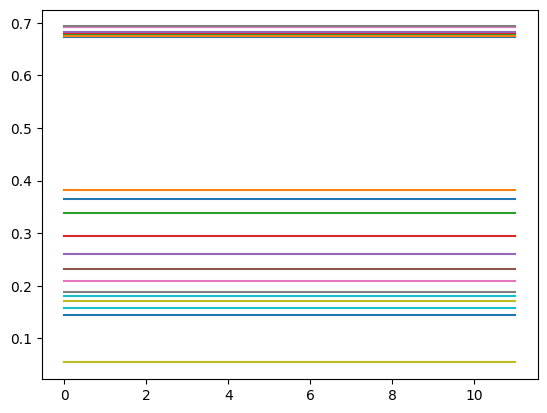

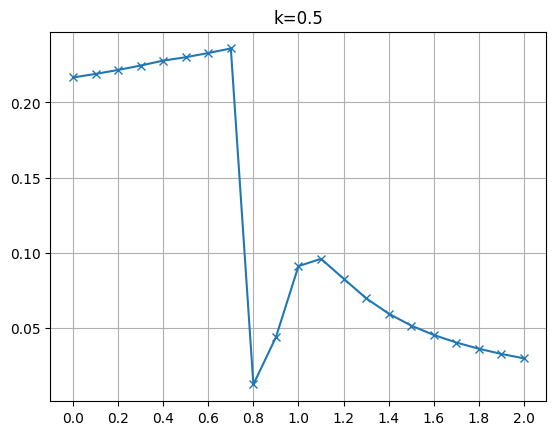

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


In [19]:
# results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states1"
var_num = len(values)
def entanglement_site(psi, basis):
    L = int(np.log2(len(psi)))
    mid = list(range(L//2))
    ent_mid = basis.ent_entropy(psi, sub_sys_A=mid)["Sent_A"]
    return ent_mid

def entanglement_string(psi, basis):
    s_sites = []
    L = int(np.log2(len(psi)))

    for i in range(L):
        ent = basis.ent_entropy(psi, sub_sys_A=[i])
        s_sites.append(ent["Sent_A"])

    return s_sites

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []


for ind, i in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results,i))
    
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_site(psi, basis))
    half_chain_entropy = entanglement_string(psi, basis)
    plt.plot(half_chain_entropy, label=f"{i}")
# plt.legend()
plt.show()
plt.grid()
plt.title(f"{opp}={set}")
plt.xticks(values[::2])
plt.plot(values, single_site_entropy_curves, marker="x")
plt.show()
print(values)


## Correlator

41it [00:00, 399.80it/s]


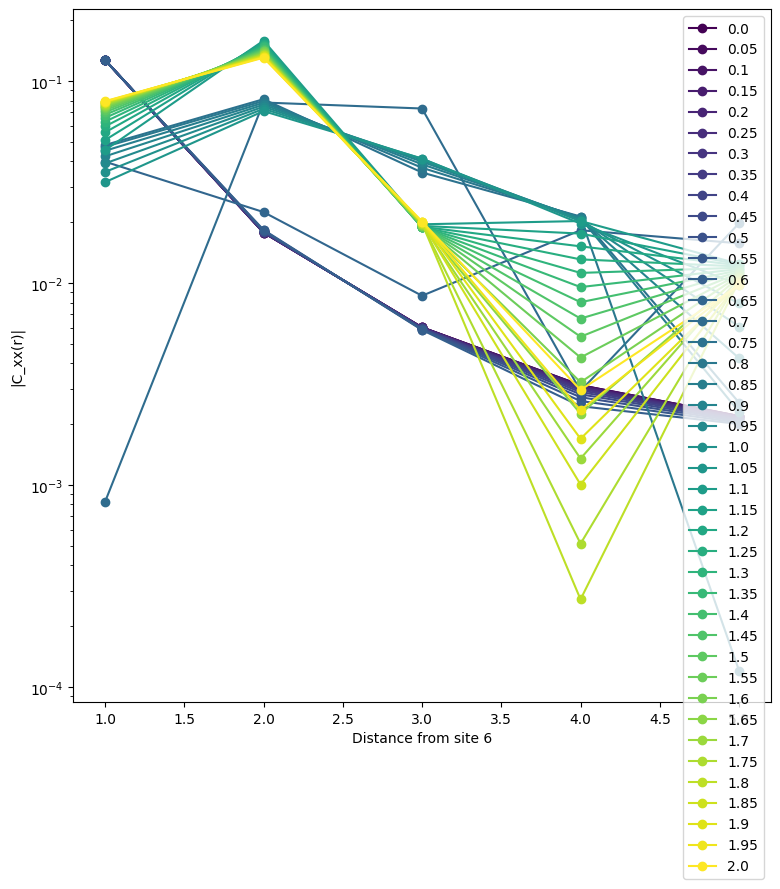

In [180]:
def correlator(op1, op2, i, j, psi, basis, dist=1):
    '''Connected correlator: g(op1, op2) = <op1_i op2_j> - <op1_i><op2_j>'''
    positions_i = [(i+dist*x)%L for x in range(len(op1))]
    positions_j = [(j+dist*y)%L for y in range(len(op2))]

    operators = [[op1+op2, [[1.0] + positions_i + positions_j]]]
    # print(operators)
    corr_op = quantum_LinearOperator(operators, basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    corr = corr_op.expt_value(psi)
    
    op_i = quantum_LinearOperator([[op1, [[1.0] + positions_i]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_i = op_i.expt_value(psi)
    
    op_j = quantum_LinearOperator([[op2, [[1.0] + positions_j]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_j = op_j.expt_value(psi)

    connected_correlator = corr - (exp_i * exp_j)
    return connected_correlator

def correlator_string(op1, op2, psi, basis, reference_site=None, bc="pbc"):
    '''Calculate correlations from one reference site to all other sites'''
    L = basis.N
    
    # Use middle site as default reference to minimize boundary effects
    if reference_site is None:
        reference_site = 0
    
    distances = []
    correlations = []
    
    for j in range(L):
        if j <= reference_site:
            continue  # Skip self-correlation
            
        if bc == "pbc":
            # For PBC, use minimum image convention
            dist = min(abs(j - reference_site), L - abs(j - reference_site))
            dist = abs(j - reference_site)
        else:
            dist = abs(j - reference_site)
            
        corr_val = correlator(op1, op2, reference_site, j, psi, basis)
        
        distances.append(dist)
        correlations.append(corr_val)
    
    return distances, correlations

# Usage - pick one consistent reference site
reference_site = L//2  # Middle of the chain
plt.figure(figsize=(9,9))

col = plt.cm.viridis(np.linspace(0, 1, 41))

for ind, filename in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results, filename))
    
    # Calculate correlations from the same reference site for all states
    distance, corr = correlator_string("z", "z", psi, basis, reference_site=reference_site, bc="pbc")
    tag = float(filename.split("_")[2])
    plt.semilogy(distance, np.abs(corr),'o-', label=f"{tag}",color=col[ind])

plt.xlabel(f'Distance from site {reference_site}')
plt.ylabel('|C_xx(r)|')
plt.legend()
plt.show()

## Central Charge

0it [00:00, ?it/s]/tmp/ipykernel_75188/1857814191.py:63: RuntimeWarning: divide by zero encountered in log
  x0 = np.log((L/np.pi) * np.sin(np.pi * positions / L))  # linearize
/tmp/ipykernel_75188/1857814191.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(s_calabrese_cardy, x0[1:L//2+1], S[1:L//2+1])


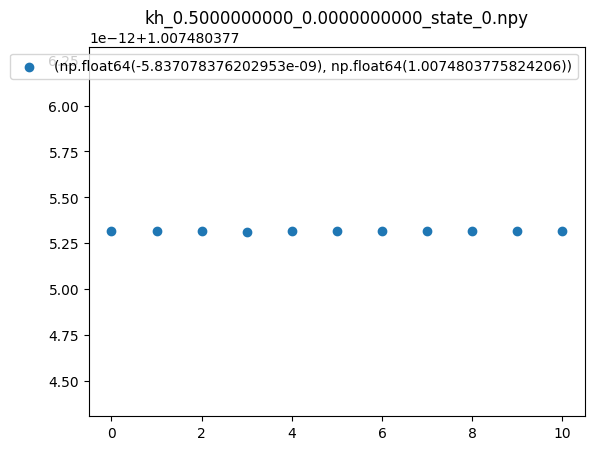

1it [00:00,  4.48it/s]

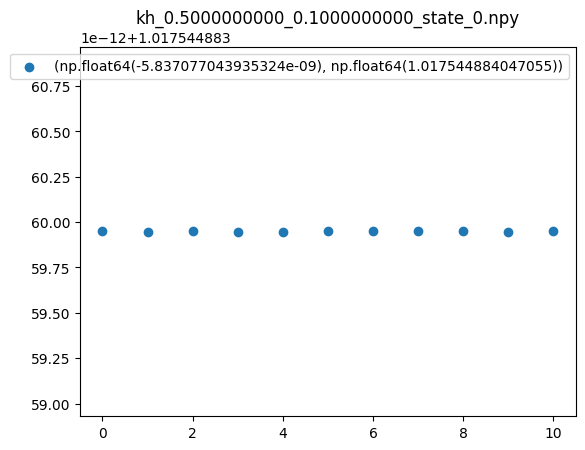

2it [00:00,  4.97it/s]

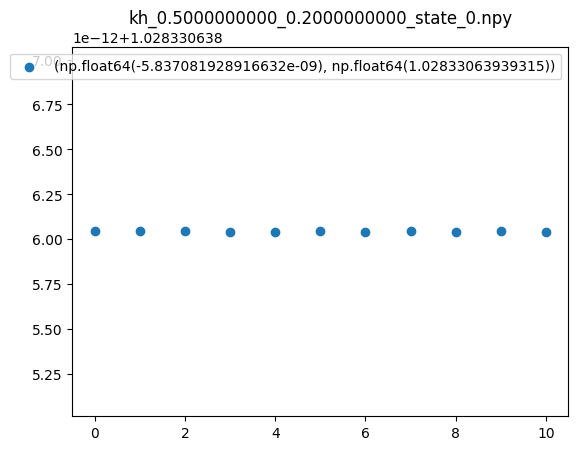

3it [00:00,  4.82it/s]

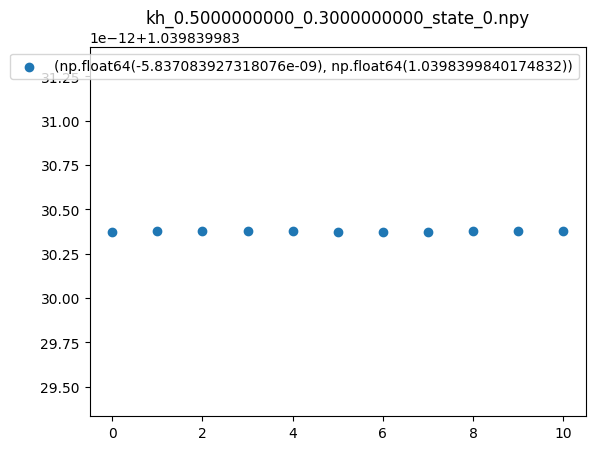

4it [00:00,  5.05it/s]

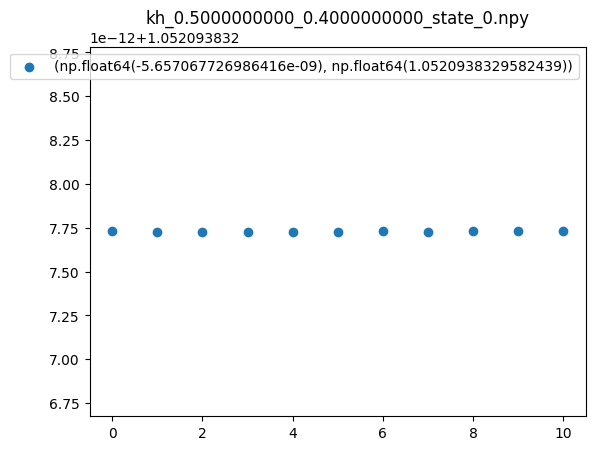

5it [00:01,  4.74it/s]

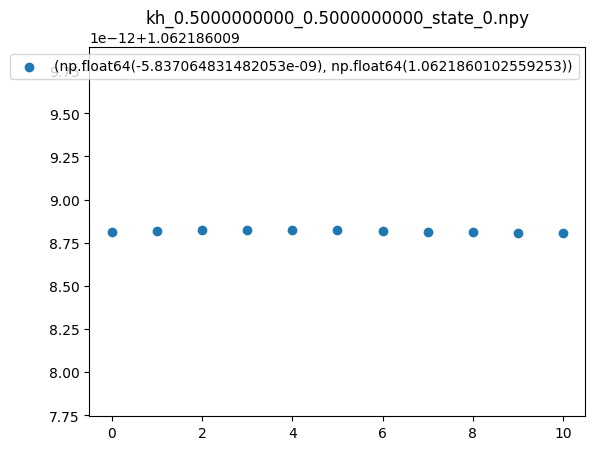

6it [00:01,  4.96it/s]

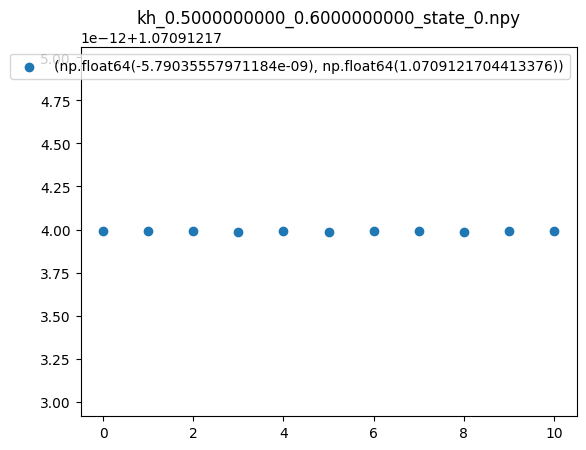

7it [00:01,  4.95it/s]

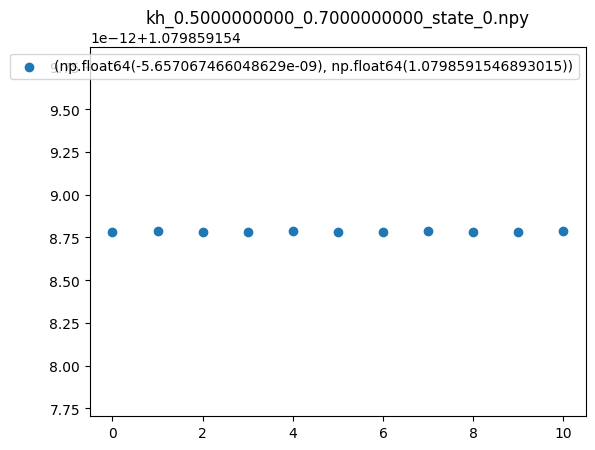

8it [00:01,  4.90it/s]

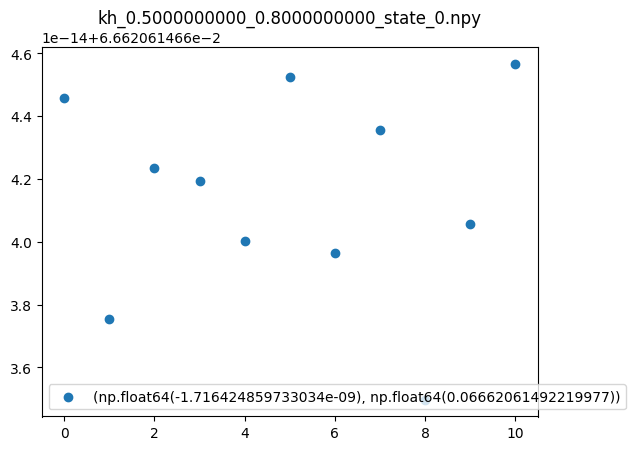

9it [00:01,  4.06it/s]

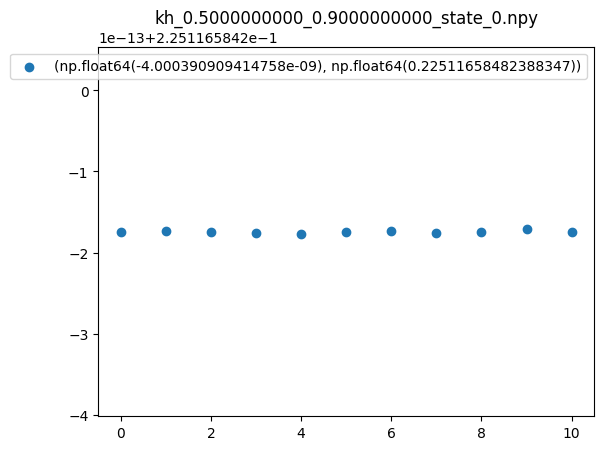

10it [00:02,  4.20it/s]

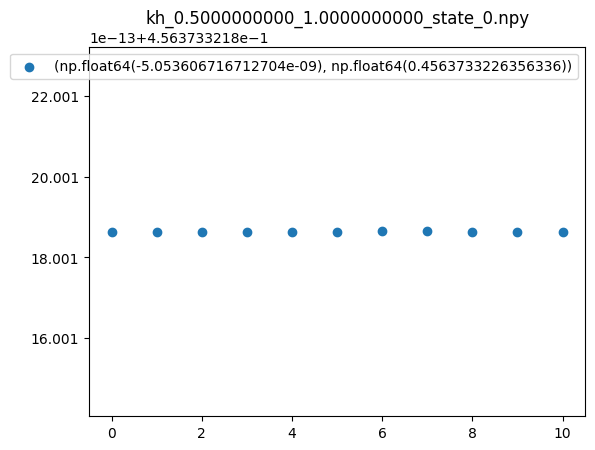

11it [00:02,  4.19it/s]

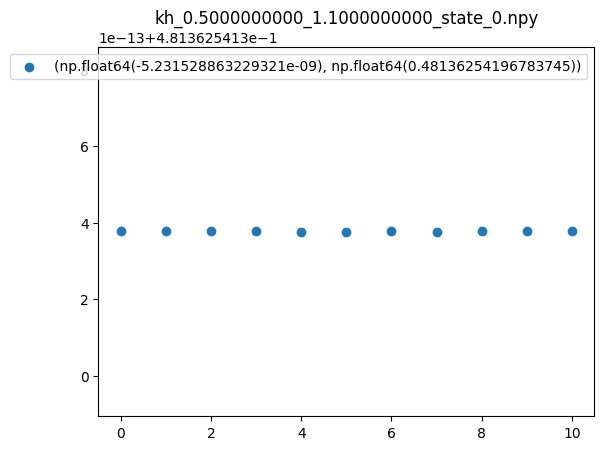

12it [00:02,  4.06it/s]

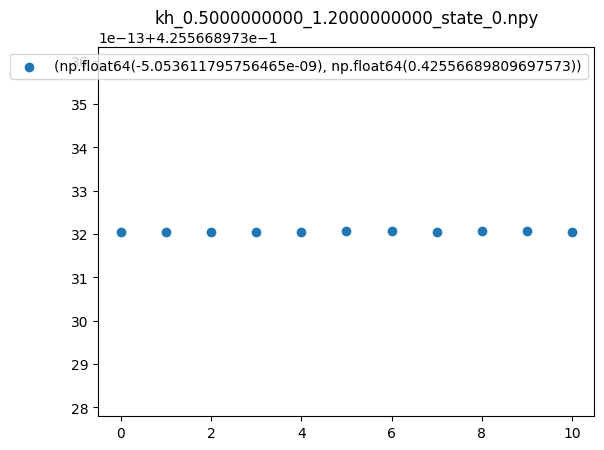

13it [00:02,  3.91it/s]

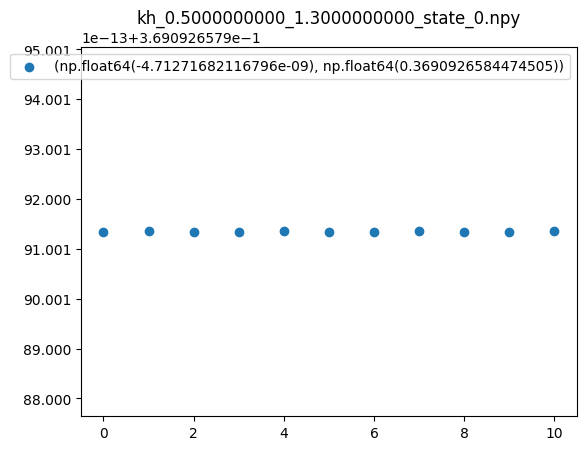

14it [00:03,  3.93it/s]

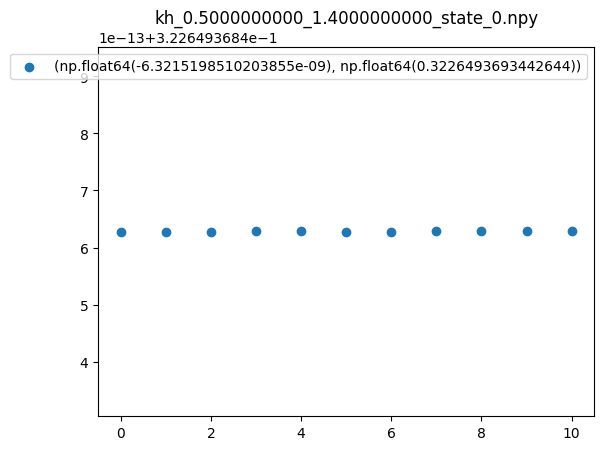

15it [00:03,  3.99it/s]

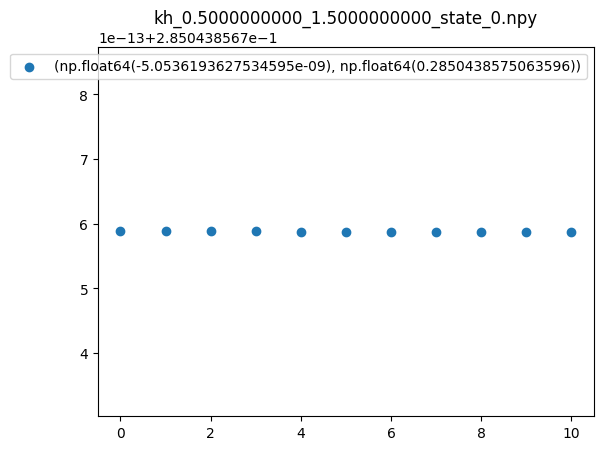

16it [00:03,  4.03it/s]

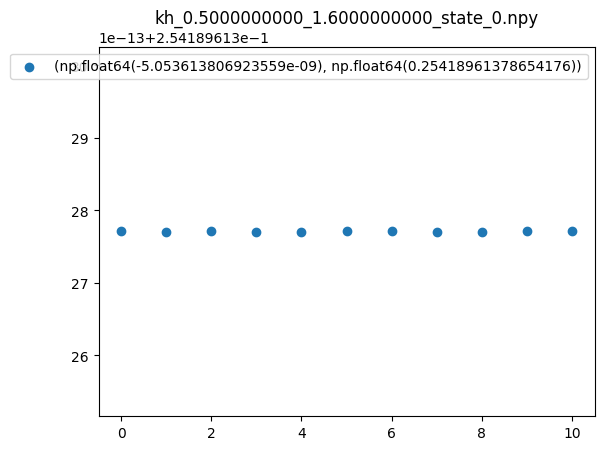

17it [00:03,  3.94it/s]

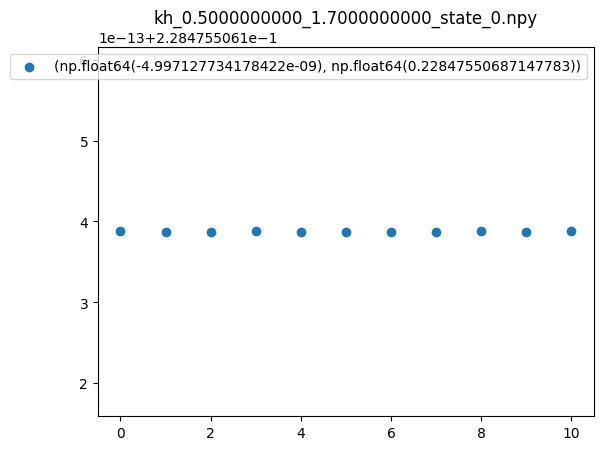

18it [00:04,  4.28it/s]

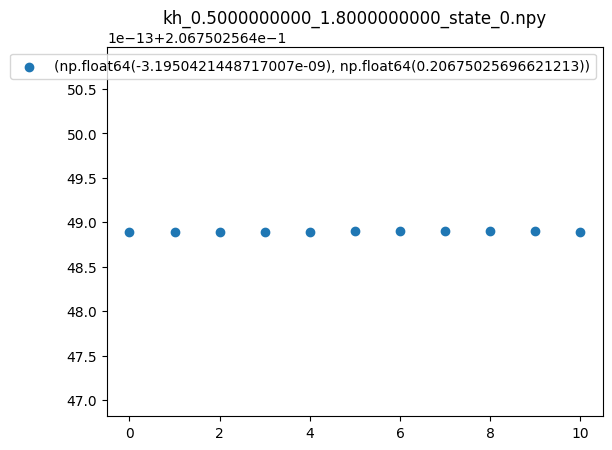

19it [00:04,  4.48it/s]

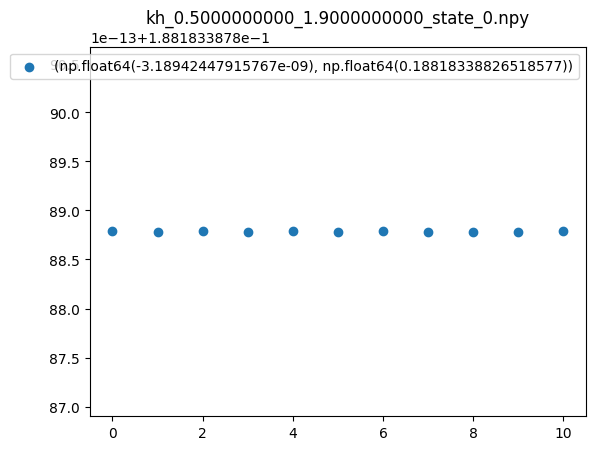

20it [00:04,  4.71it/s]

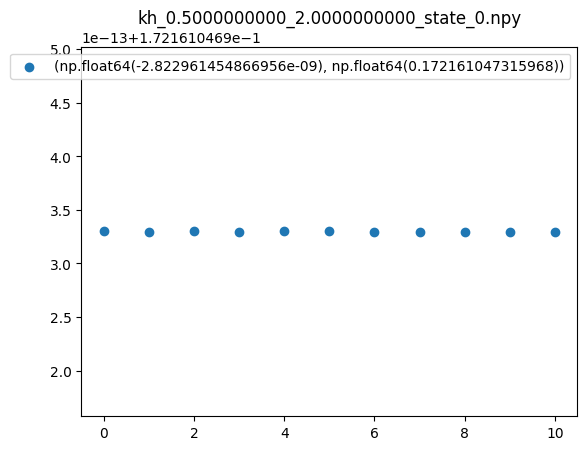

21it [00:04,  4.39it/s]


In [ ]:
from scipy.optimize import curve_fit

# Calculate central charge
# results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"

def bond_entanglement_entropy(psi, basis, site_i, site_j):
    """
    Calculate entanglement entropy between two sites i and j.
    
    Parameters:
    psi: ground state wavefunction
    basis: QuSpin basis object
    site_i, site_j: indices of the two sites (should be neighbors for S(i,i+1))
    
    Returns:
    S: von Neumann entanglement entropy between sites i and j
    """
    # Create list of sites for the reduced density matrix
    sites = [site_i, site_j]
    rho_ij = basis.partial_trace(psi, sites)
    eigvals = np.linalg.eigvalsh(rho_ij)
    eigvals = eigvals[eigvals > 1e-15]
    S = -np.sum(eigvals * np.log(eigvals))
    
    return S

def all_bond_entropies(psi, basis, L):
    """
    Calculate S(i,i+1) for all bonds in the chain.
    
    Returns:
    positions: bond positions (center between sites)
    entropies: S(i,i+1) values
    """
    positions = []
    entropies = []
    
    for i in range(L-1):  # For open boundaries
        S = bond_entanglement_entropy(psi, basis, i, i+1)
        positions.append(i)  # Bond center
        entropies.append(S)
    
    return np.array(positions), np.array(entropies)

def s_calabrese_cardy(x, c, s0):
    return (c/6) * x + s0

# def s_calabrese_cardy(x, c, s0):
#     return (c/6) * np.log((L/np.pi) * np.sin(np.pi * x / L)) + s0

for ind, i in tqdm(enumerate(sorted(os.listdir(results), key= lambda x: float(x.split("_")[2])))):
    psi = np.load(os.path.join(results,i))
    positions, S = all_bond_entropies(psi, basis, L)

    x0 = np.log((L/np.pi) * np.sin(np.pi * positions / L))  # linearize

    # fit
    popt, pcov = curve_fit(s_calabrese_cardy, x0[1:L//2+1], S[1:L//2+1])

    plt.scatter(positions, S, label=f"{popt[0], popt[1]}")
    # plt.plot(positions, s_calabrese_cardy(positions, *popt))
    plt.title(f"{i}")
    plt.legend()
    plt.show()

# Compare DMRG w/ ED

IndexError: list index out of range

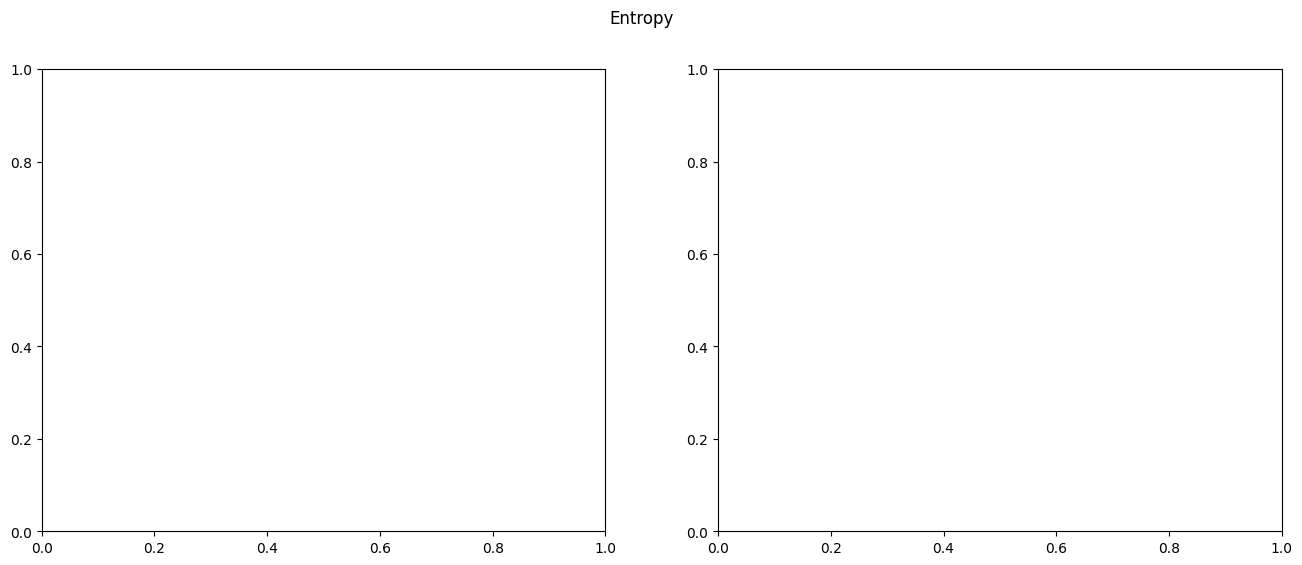

In [32]:
# --- entropy ---
filename= os.path.join(os.getcwd(), f"dmrg_results/run_L{L+4}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}")

def plot_entropy(dmrg_path, single_site, half_chain, scan_var, values, opp, set):
    fig, ax = plt.subplots(1, 2, figsize=(16,6))
    fig.suptitle("Entropy")

    s_mid = []

    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0.3, 0.85, len(values)))

    for i, (v, c) in enumerate(zip(values, colors)):
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/S.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/S.txt")
        try:
            ind, _, s = np.loadtxt(loc, dtype=np.complex128).T
            ind = [i - 2 for i in ind]
            mid_site = len(s) // 2
            s_mid.append(s[mid_site])
            ax[0].plot(ind, s, ls="--", color=c)  # DMRG
        except Exception:
            # No DMRG data → skip plotting
            pass

        ax[0].plot(single_site[i], color=c, label=f"ED, {scan_var}={v:.2f}")

    ax[0].set_title(f"Single-site entanglement entropy for {opp}={set}")
    ax[0].legend()

    # --- half-chain entropy compare ---
    ax[1].plot(values, half_chain, "-o", label="ED")
    if len(s_mid) == len(values):
        ax[1].plot(values, s_mid, "x-", color="red", label="DMRG")

    ax[1].set_title(f"Half-chain entanglement vs {scan_var}")
    ax[1].set_xlabel(f"{scan_var}")
    ax[1].set_ylabel("S_half")
    ax[1].legend()

    plt.grid()
    plt.show()


plot_entropy(filename, single_site_entropy_curves, half_chain_entropy, values=values, scan_var=scan_var, opp=opp, set=set)

In [ ]:
# --- string magnetization ----
def plot_string(dmrg_path, op, values, string_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0, 0.5, len(values)))
    plt.figure(figsize=(6, 6))
    for ind, (v, c) in enumerate(zip(values, colors)):
        

        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        # --- Try loading DMRG file ---
        try:
            index_dmrg, site_measurements_dmrg = np.loadtxt(loc).T
            has_dmrg = True
        except Exception:
            has_dmrg = False

        # --- ED ---
        plt.plot(
            range(len(string_measurements_ed.T)),
            string_measurements_ed[ind],
            label=f"{v}",
            color=c
        )

        # --- DMRG (optional) ---
        if has_dmrg:
            plt.scatter(
                [i-2 for i in index_dmrg],
                site_measurements_dmrg,
                marker="x",
                color=c,
            )

    plt.title(f"Magnetization {op} (string) for {opp}={set}")
    plt.xlabel("Site index")
    plt.ylabel(f"{op}")
    plt.ylim(-1, 1)
    plt.legend()
    plt.grid()
    plt.show()


plot_string(filename, 'X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

IndexError: list index out of range

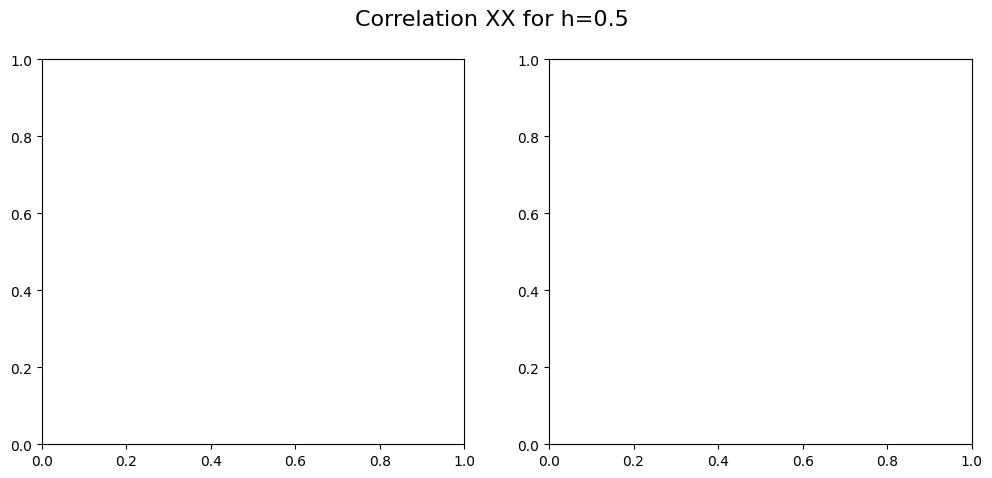

In [ ]:
def plot_correlator_simple(dmrg_path, op, values, ed_distances, ed_correlations, scan_var, opp, set_val, orientation="semilogy"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Correlation {op} for {opp}={set_val}", fontsize=16)

    # Colormaps
    cmap_ed = plt.cm.viridis
    cmap_dmrg = plt.cm.inferno
    colors_ed = cmap_ed(np.linspace(0, 1, len(values)))
    colors_dmrg = cmap_dmrg(np.linspace(0, 1, len(values)))

    L = len(ed_correlations[0]) + 1  # +1 because we skipped self-correlation
    
    for ind, (v, c_ed, c_dmrg) in enumerate(zip(values, colors_ed, colors_dmrg)):
        # ---------------- ED DATA ----------------
        x_ed = [L - i  for i in ed_distances[ind]]
        y_ed = ed_correlations[ind]  # Use real part to see signs
        label_ed = f"{scan_var}={v:.2f}"

        # ---------------- DMRG DATA ----------------
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set_val:.2f}_{set_val:.2f}/OUT/out_{v:.3f}_{set_val:.3f}_{set_val:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set_val:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set_val:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        x_dmrg, y_dmrg = [], []

        if os.path.exists(loc):
            try:
                r = np.loadtxt(loc, dtype=np.complex128)
                if r.ndim == 1:
                    r = r.reshape(1, -1)
                for row in r:
                    i, j, corr = row
                    if int(i) == (L+4)//2:
                        print(i, j)
                        distance = np.abs(int(j) - int(i))
                        x_dmrg.append(distance)
                        y_dmrg.append(corr)
            except Exception as e:
                pass

        # ---------------- PLOTTING ----------------
        if orientation == "semilogy":
            ax[0].semilogy(x_ed, np.abs(y_ed), "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].semilogy(x_dmrg, np.abs(y_dmrg), "-x", color=c_ed, label=label_ed)
        elif orientation == "loglog":
            ax[0].loglog(x_ed, np.abs(y_ed), "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].loglog(x_dmrg, np.abs(y_dmrg), "-x", color=c_ed, label=label_ed)
        else:
            ax[0].plot(x_ed, y_ed, "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].plot(x_dmrg, y_dmrg, "-x", color=c_ed, label=label_ed)

    # ---------------- AXIS SETUP ----------------
    ax[0].set_xlabel("Distance from site 2")
    ax[0].set_ylabel(f"⟨{op}⟩")
    ax[0].grid(True)
    # ax[0].legend()

    ax[1].set_xlabel("Distance from middle site")
    ax[1].set_ylabel(f"⟨{op}⟩")
    ax[1].grid(True)
    # ax[1].legend()

    plt.tight_layout()
    plt.show()


# GRAVEYARD

In [ ]:
# def plot_string(dmrg_path, op, values, string_measurements_ed, scan_var, opp, set, counter=False, colors="black"):
#     # cmap = plt.cm.inferno
#     # colors = cmap(np.linspace(0, 0.5, len(values)))

#     for ind, (v, c) in enumerate(zip(values, colors)):
#         if scan_var == "h":
#             loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
#         else:
#             loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

#         # --- Try loading DMRG file ---
#         try:
#             index_dmrg, site_measurements_dmrg = np.loadtxt(loc).T
#             has_dmrg = True
#         except Exception:
#             has_dmrg = False
#         label = f"{v}, {counters}" if counter else f"{v}"
#         color = colors[counter%4] if counter else "black"
#         # --- ED ---
#         plt.plot(
#             string_measurements_ed,
#             label=label,
#             color=color
#         )

#         # --- DMRG (optional) ---
#         if has_dmrg:
#             plt.scatter(
#                 [i-2 for i in index_dmrg],
#                 site_measurements_dmrg,
#                 marker="x"
#                 # color=c,
#             )

#     plt.title(f"Magnetization {op} (string) for {opp}={set}")
#     plt.xlabel("Site index")
#     plt.ylabel(f"{op}")
#     plt.ylim(-1, 1)
#     plt.legend()
#     plt.grid()

In [ ]:
# --- site magnetization ---
def plot_site(dmrg_path, op, values, site_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    cmap2 = plt.cm.viridis
    color = cmap(0.6)
    color2 = cmap2(0.6)

    site_measurements_dmrg = []
    loc = os.path.join(dmrg_path, f"*/OUT/*/{op}.txt")

    dmrg_files = sorted(glob.glob(loc))

    for i in dmrg_files:
        try:
            r = np.loadtxt(i).T[1]
            if op == "X":
                site_measurements_dmrg.append(0.5*(r[int(len(r)//2)]-r[int(len(r)//2)+1]))
            else:
                site_measurements_dmrg.append(r[int(len(r)//2)])
        except Exception:
            continue   # skip missing or broken files

    # --- always plot ED ---
    plt.plot(values, site_measurements_ed, "-o", color=color,label="ED")

    # --- plot DMRG only if available ---
    if len(site_measurements_dmrg) == len(values):
        plt.plot(values, site_measurements_dmrg, "-x", color=color2, label="DMRG")

    plt.title(f"Mid-chain magnetization of {op} vs {scan_var} at {opp}={set}")
    plt.xlabel(scan_var)
    plt.legend()
    plt.grid()
    plt.show()

plot_site(filename, 'X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)